In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/cleaned/uber_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (195065, 11)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,Thursday,5,2015
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,Friday,7,2009
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,Monday,8,2009
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,Friday,6,2009
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,Thursday,8,2014


In [3]:
#  We will only be taking 2 features for segmentation 
features = df[['fare_amount', 'passenger_count']]

print("Features selected:")
print(features.describe())

Features selected:
         fare_amount  passenger_count
count  195065.000000    195065.000000
mean       11.344597         1.689750
std         9.704250         1.305593
min         2.500000         1.000000
25%         6.000000         1.000000
50%         8.500000         1.000000
75%        12.500000         2.000000
max       200.000000         6.000000


In [4]:
# Scale the Data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Data scaled successfully!")
print("Shape:", features_scaled.shape)

Data scaled successfully!
Shape: (195065, 2)


In [5]:
# Train KMeans model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(features_scaled)

# Add cluster labels to dataframe
df['cluster'] = kmeans.labels_

print("KMeans model complete!")
print("\nRiders per cluster:")
print(df['cluster'].value_counts())

KMeans model complete!

Riders per cluster:
cluster
0    152380
2     29320
1     13365
Name: count, dtype: int64


In [6]:
# Check average fare per cluster
cluster_summary = df.groupby('cluster')['fare_amount'].mean().sort_values()
print("Average fare per cluster:")
print(cluster_summary)

# Assign names based on fare amount
cluster_names = {
    cluster_summary.index[0]: 'Low Value',
    cluster_summary.index[1]: 'Mid Value', 
    cluster_summary.index[2]: 'High Value'
}

df['rider_segment'] = df['cluster'].map(cluster_names)

print("\nRiders per segment:")
print(df['rider_segment'].value_counts())

Average fare per cluster:
cluster
0     9.128992
2     9.808643
1    39.975210
Name: fare_amount, dtype: float64

Riders per segment:
rider_segment
Low Value     152380
Mid Value      29320
High Value     13365
Name: count, dtype: int64


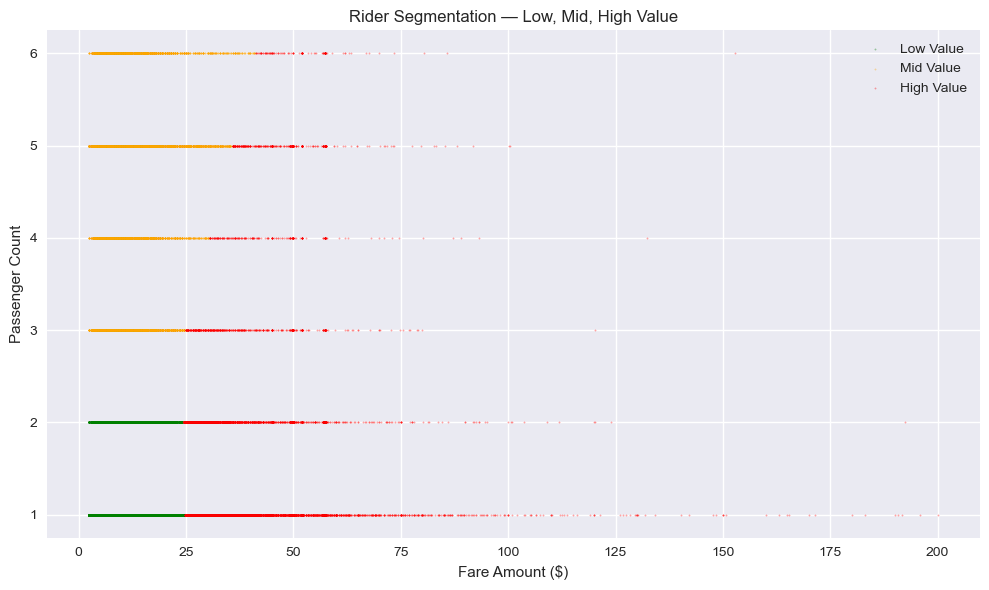

In [7]:
# Scatter plot for rider segments
plt.figure(figsize=(10, 6))

colors = {'Low Value': 'green', 'Mid Value': 'orange', 'High Value': 'red'}

for segment, color in colors.items():
    mask = df['rider_segment'] == segment
    plt.scatter(df[mask]['fare_amount'], 
                df[mask]['passenger_count'],
                c=color, label=segment, alpha=0.3, s=1)

plt.title('Rider Segmentation — Low, Mid, High Value')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Passenger Count')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print("=" * 50)
print("RIDER SEGMENTATION — BUSINESS CONCLUSION")
print("=" * 50)

for segment in ['Low Value', 'Mid Value', 'High Value']:
    mask = df['rider_segment'] == segment
    print(f"""
Segment: {segment}
Total Riders : {mask.sum()}
Avg Fare     : ${df[mask]['fare_amount'].mean():.2f}
Avg Passengers: {df[mask]['passenger_count'].mean():.1f}
""")

print("=" * 50)
print("""
BUSINESS RECOMMENDATIONS:

Low Value Riders:
- Offer discount coupons to increase ride frequency

Mid Value Riders:
- Target with loyalty rewards program

High Value Riders:
- Offer Uber Premium subscription
- Priority driver matching
""")
print("=" * 50)

RIDER SEGMENTATION — BUSINESS CONCLUSION

Segment: Low Value
Total Riders : 152380
Avg Fare     : $9.13
Avg Passengers: 1.2


Segment: Mid Value
Total Riders : 29320
Avg Fare     : $9.81
Avg Passengers: 4.5


Segment: High Value
Total Riders : 13365
Avg Fare     : $39.98
Avg Passengers: 1.5


BUSINESS RECOMMENDATIONS:

Low Value Riders:
- Offer discount coupons to increase ride frequency

Mid Value Riders:
- Target with loyalty rewards program

High Value Riders:
- Offer Uber Premium subscription
- Priority driver matching

